## Генерация текста RNN моделью
### Генерация поэзии с помощью нейронных сетей: шаг 1


Наша основная задача: научиться генерировать стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [1]:

import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# Переносим наше устройство а GPU

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))


cuda device is available


#### 1. Загрузка данных.

In [3]:

!wget https://raw.githubusercontent.com/MSUcourses/Data-Analysis-with-Python/main/Deep%20Learning/onegin_hw07.txt -O ./onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = "".join([x.replace('\t\t', '').lower() for x in text]) # Убираем лишние символы табуляций, приводим все буквы к нижнему регистру


--2025-03-02 15:06:45--  https://raw.githubusercontent.com/MSUcourses/Data-Analysis-with-Python/main/Deep%20Learning/onegin_hw07.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘./onegin.txt’

./onegin.txt        100%[===================>] 256.37K  --.-KB/s    in 0.02s   

2025-03-02 15:06:45 (10.5 MB/s) - ‘./onegin.txt’ saved [262521/262521]



Выведем несколько первых символов входного текста. Видим, что символы табуляций удалены, буквы приведены к нижнему регистру. Символы \n мы оставляем - чтобы научить сеть генерировать символ \n, когда нужно перейти на новую строку.

In [4]:
text[:36]

'\ni\n\n«мой дядя самых честных правил,\n'

#### 2. Построение словаря и предобработка текста
На данном этапе требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим технический токен `<sos>`.

In [5]:

tokens = sorted(set(text.lower())) + ['<sos>'] # Строим множество всех токенов-символов и добавляем к нему служебный токен <sos>
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)} # Строим словарь с ключами-токенами и значениями-индексами в списке токенов
idx_to_token = {idx: x for idx, x in enumerate(tokens)} # Строим обратный словарь (чтобы по индексу можно было получить токен)

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]


Seems fine!


__Наша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Далее для  удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [6]:

batch_size = 256 # Размер батча. Батч - это набор последовательностей символов.
seq_length = 100 # Максимальная длина одной последовательности символов в батче
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>'] # Добавляем в начало каждой строки технический символ - для определения начального состояния сети

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1) # Случайным образом выбираем индекс начального символа в батче
    # Строим непрерывный батч.
    # Для этого выбираем в исходном тексте подпоследовательность, которая начинается с индекса start_index и имеет размер batch_size*seq_length.
    # Затем мы делим эту подпоследовательность на batch_size последовательностей размера seq_length. Это и будет батч, матрица размера batch_size*seq_length.
    # В каждой строке матрицы будут указаны индексы
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
#

Пример батча:

In [7]:
next(generate_chunk())

array([[83, 49, 45, ..., 62, 55, 53],
       [83, 66,  1, ..., 47, 59, 51],
       [83, 45, 63, ...,  2,  1, 48],
       ...,
       [83, 64, 51, ..., 44,  0, 78],
       [83,  1, 64, ..., 50,  1, 57],
       [83, 59, 48, ..., 63, 76, 57]])

Далее вам предстоит написать код для обучения модели и генерации текста.

In [8]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(VanillaRNN, self).__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np


In [10]:
hidden_size, num_layers=100,2

In [11]:
# Задание модели
model = VanillaRNN(num_tokens, hidden_size, num_layers)
opt = torch.optim.Adam(model.parameters())
criterion = nn.NLLLoss()

In [12]:
batch_generator = generate_chunk()
batch_data = next(batch_generator)

# Преобразование входных данных в тензор
batch_ix = torch.tensor(batch_data, dtype=torch.long)

# Подача данных на вход модели
logits = model(batch_ix)

In [13]:
logits.shape

torch.Size([256, 101, 84])

In [14]:
predictions_logp = F.log_softmax(logits[:, :-1], dim=-1)                          # все кроме последнего предсказания, т.к. в конце последовательности нам не нужно ничего предсказывать
actual_next_tokens = batch_ix[:, 1:]                                              # наши правильные ответы (все что есть, начиная с 1 шага), исключаем первый шаг, т.к. в начале мы находились в нулевом состоянии и ничего не предсказывали

loss = criterion(                                                                 # считаем функцию ошибки от предсказаний и истинных значений
    predictions_logp.contiguous().view(-1, num_tokens),                           # вытягиваем все в один батч (т.е. из размерности (batch, time, prob) переходим к (batch*time, prob))
    actual_next_tokens.contiguous().view(-1)
)

loss.backward()

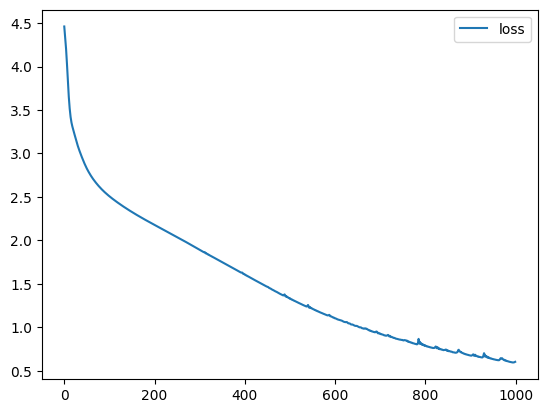

In [15]:
MAX_LENGTH = 16
history = []

for i in range(1000):                                                             # всего 1000 итераций

    batch_generator = generate_chunk()
    batch_data = next(batch_generator)

# Преобразование входных данных в тензор
    batch_ix = torch.LongTensor(batch_ix)                                         # преобразовали в тензор

    logits = model(batch_ix)                                                    # получили последовательность logp

    # Считаем loss
    predictions_logp = F.log_softmax(logits[:, :-1], dim=-1)
    actual_next_tokens = batch_ix[:, 1:]

    loss = criterion(
        predictions_logp.contiguous().view(-1, num_tokens),
        actual_next_tokens.contiguous().view(-1)
    )

    # Обучение методов backprop
    loss.backward()                                                               # посчитали градиенты
    opt.step()
    opt.zero_grad()                                                                  # сделали шаг

    # код отрисовки графика
    history.append(loss.item())
    if (i+1)%100==0:                                                              # на каждом сотом шаге обновляем график
        clear_output(True)
        plt.plot(history,label='loss')
        plt.legend()
        plt.show()

assert np.mean(history[:10]) > np.mean(history[-10:]), "RNN didn't converge."

Реализация функции `generate_sample`

In [16]:


def generate_sample(model, seed_phrase=' ', max_length=MAX_LENGTH, temperature=1.0):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''

    x_sequence = [token_to_idx[token] for token in seed_phrase]                    # преобразуем seed_phrase в последовательность индексов токенов
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64)

    #start generating
    for _ in range(max_length - len(seed_phrase)):
        logits = model(x_sequence)                                                # новое скрытое состояние и логит для след токена - это
                                                                                  # последний элемент последовательности и текущее скрытое состояние
        p_next = F.softmax(logits / temperature, dim=-1).data.numpy()[0][-1]      # считаем вероятность: softmax от текущих логитов
                                                                                  # temperature отвечает за случайность (гиперпараметр)

        # sample next token and push it back into x_sequence
        next_ix = np.random.choice(num_tokens,p=p_next)                           # из всех токенов с распределением p_next
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
        x_sequence = torch.cat([x_sequence, next_ix], dim=1)                      # добавляем к последовательности

    return ''.join([tokens[ix] for ix in x_sequence.data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [17]:

print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

 мой дядя самых честных правили
ее присез моду, волцуемале старел,
и теперкенитьмы меня?



viii

что ж туманцем и мной толстатей,
чег данной расскокой.



xxvii

так гак влашь ж умы плакот, и деве пам, что ю, ляня:
я, него брат намя
бодгустать.
в дел ввелил уж тескла,
не славить поленная веницый,
нагод том.
в лете ни б, бывала след.
таской стоны.
– «нать,
всогданцем рузлыха,
нехасял посходительный мостай
и мира новы,
и сожеровила ка к вотраделий уговый прикупосмелы
и другу
к оннаядьслу;
татьяны


### Сдача задания
Сгенерируем десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудем удалить все технические токены в случае их наличия.



In [18]:
seed_phrase = ' мой дядя самых честных правил'

In [19]:
generated_phrases = [
     generate_sample(
        model,
        ' мой дядя самых честных правил',
        max_length=500,
        temperature=1.
    ).replace('<sos>', '')
    for _ in range(10)
]


In [20]:


if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'


submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

np.save('submission_dict_hw07.npy', submission_dict, allow_pickle=True)


File saved to `submission_dict_hw07.npy`
